In [1]:
import numpy as np
import pandas as pd
import pykeen

In [2]:
kg = pd.read_csv("../knowledge-graphs/props_wikidata_movielens_small.csv")
kg.head()

,movieId,title,prop,obj,imdbId
0,199,The Umbrellas of Cherbourg,director,Jacques Demy,tt0058450
1,199,The Umbrellas of Cherbourg,screenwriter,Jacques Demy,tt0058450
2,199,The Umbrellas of Cherbourg,composer,Michel Legrand,tt0058450
3,199,The Umbrellas of Cherbourg,genre,drama,tt0058450
4,199,The Umbrellas of Cherbourg,genre,musical film,tt0058450


In [3]:
kg[['movieId', 'prop', 'obj']].astype(str).values

array([['199', 'director', 'Jacques Demy'],
       ['199', 'screenwriter', 'Jacques Demy'],
       ['199', 'composer', 'Michel Legrand'],
       ...,
       ['179053', 'country of origin', 'United States of America'],
       ['179053', 'narrative location', 'Los Angeles'],
       ['179053', 'title', '2048: Nowhere to Run']], dtype=object)

In [4]:
from pykeen.triples import TriplesFactory

tf = TriplesFactory.from_labeled_triples(triples=kg[['movieId', 'prop', 'obj']].astype(str).values)
train, validation, test = tf.split([0.8, 0.1, 0.1], random_state=42)

In [5]:
tf

TriplesFactory(num_entities=79008, num_relations=23, create_inverse_triples=False, num_triples=295700)

In [6]:
print(f'''Training Data: \t{train}''')
print(f'''Training Data: \t{validation}''')
print(f'''Test Data: \t{test}''')

Training Data: 	TriplesFactory(num_entities=79008, num_relations=23, create_inverse_triples=False, num_triples=236560)
Training Data: 	TriplesFactory(num_entities=79008, num_relations=23, create_inverse_triples=False, num_triples=29570)
Test Data: 	TriplesFactory(num_entities=79008, num_relations=23, create_inverse_triples=False, num_triples=29570)


In [7]:
print(train.num_triples + validation.num_triples + test.num_triples)
print(tf.num_triples)

295700
295700


In [ ]:
from pykeen.pipeline import pipeline
from torch import nn

pipeline_result = pipeline(
    training=train,
    validation=validation,
    testing=test,
    model='Rotate',
    model_kwargs=dict(
        embedding_dim=128,
    ),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.001),
    loss='NSSALoss',
    random_seed=42,
    device='cuda',
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=5, filtered=True),
    stopper='early',
    use_testing_data=False,
    stopper_kwargs=dict(frequency=5, patience=3, relative_delta=0.002,
                            metric='hits@5', larger_is_better=True),
    training_loop='sLCWA',
    training_kwargs=dict(num_epochs=30, batch_size=512),
)

INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: C:\Users\andre\.data\pykeen\checkpoints\best-model-weights-99d27db8-d950-425e-b017-7e58f2c3fb52.pt


Training epochs on cuda:0:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 414.94s seconds
INFO:pykeen.stoppers.early_stopping:Stopping early at epoch 20. The best result 0.06657084883327696 occurred at epoch 5.
INFO:pykeen.stoppers.early_stopping:Re-loading weights from best epoch from C:\Users\andre\.data\pykeen\checkpoints\best-model-weights-99d27db8-d950-425e-b017-7e58f2c3fb52.pt


Evaluating on cuda:0:   0%|          | 0.00/29.6k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 443.62s seconds


<Axes: title={'center': 'Losses Plot'}, xlabel='Epoch', ylabel='bcewithlogits Loss'>

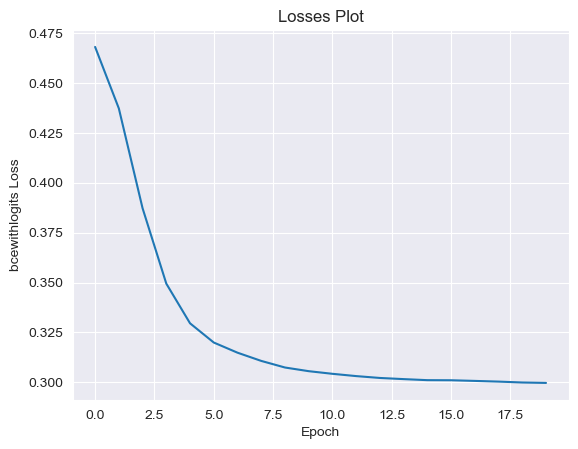

In [19]:
pipeline_result.plot_losses()

In [20]:
print(f"Hits@1: {pipeline_result.get_metric('hits@1')}")
print(f"Hits@3: {pipeline_result.get_metric('hits@3')}")
print(f"Hits@5: {pipeline_result.get_metric('hits@5')}")
print(f"Hits@10: {pipeline_result.get_metric('hits@10')}")
print(f"Mean Reciprocal Rank: {pipeline_result.get_metric('mean_reciprocal_rank')}")

Hits@1: 0.024890091308758876
Hits@3: 0.051065268853567804
Hits@5: 0.06638484950963815
Hits@10: 0.09296584376056814
Mean Reciprocal Rank: 0.04869605973362923


In [ ]:
pipeline_result.model.entity_representations[0]

Embedding(
  (_embeddings): Embedding(79008, 256)
)

In [44]:
entity_embeds = pd.DataFrame(pipeline_result.model.entity_representations[0](indices=None).detach().cpu().numpy()).rename(
            tf.entity_id_to_label)
relation_embeds = pd.DataFrame(pipeline_result.model.relation_representations[0](indices=None).detach().cpu().numpy()).rename(
            tf.relation_id_to_label)

In [29]:
entity_embeds

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
"""Crocodile"" Dundee",-0.158820-0.269613j,0.192711-0.331537j,-0.050645-0.060916j,-0.007642+0.057805j,-0.266635+0.216389j,-0.031353+0.058126j,-0.027547-0.037273j,0.064345+0.051250j,0.154331+0.019712j,-0.156728-0.166784j,...,0.043316-0.061969j,-0.293098+0.017512j,-0.163304-0.152848j,-0.097739+0.171865j,-0.181844-0.253216j,-0.079163+0.085176j,0.013521-0.066268j,-0.334110+0.278067j,-0.132851+0.004610j,0.026933+0.191301j
"""Crocodile"" Dundee II",-0.060632-0.172883j,0.022829-0.026699j,0.057303-0.151270j,0.038031+0.282318j,-0.011409+0.226026j,-0.077672-0.089650j,0.007002-0.026001j,-0.038175-0.314889j,-0.036660+0.005665j,-0.085542-0.080298j,...,0.087409+0.122565j,0.001974-0.026139j,0.047782-0.108022j,-0.000818+0.044630j,0.023778+0.136780j,0.189200-0.253014j,-0.074702+0.055684j,-0.473338+0.274092j,-0.124301-0.057223j,-0.140765-0.003622j
"""Home Alone"" house",-0.034077-0.019867j,0.023478-0.047271j,-0.065191+0.096841j,0.000781-0.121791j,0.089243-0.102076j,-0.019921+0.079319j,-0.050199+0.167685j,-0.071564-0.077844j,-0.099461+0.178337j,-0.074604+0.136062j,...,-0.079720-0.139486j,0.219654-0.165278j,0.005881-0.256038j,0.048591+0.101244j,0.027956-0.066367j,-0.128185+0.011888j,0.138351-0.066233j,0.756716+0.061942j,0.171340-0.000456j,-0.105675-0.088025j
"""Weird Al"" Yankovic",0.044014+0.003603j,-0.056164-0.114492j,0.058073+0.000600j,0.048927-0.062709j,0.134294+0.089229j,-0.010588+0.055377j,0.013774+0.013444j,0.009055-0.026350j,-0.033806+0.002610j,-0.036229-0.140349j,...,-0.065180+0.067079j,-0.054902+0.027754j,-0.073253+0.102365j,-0.029127+0.040167j,-0.037919+0.033935j,0.001370+0.007228j,-0.005704+0.031521j,-0.463134+0.374517j,-0.070382-0.006247j,0.095105-0.038111j
'71,0.086783+0.100359j,-0.002714+0.079302j,0.173918+0.104556j,0.035703-0.255071j,-0.012713+0.403352j,-0.034638-0.164152j,0.171965+0.019174j,-0.005368-0.094181j,-0.103263-0.023841j,-0.143507+0.027488j,...,0.150280-0.147879j,0.031679-0.075038j,0.147081-0.192836j,-0.057241+0.179017j,0.219689-0.164121j,0.179470-0.190734j,0.067428+0.179681j,-0.453521+0.458696j,0.023572+0.006036j,0.088129+0.228360j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
태극기 휘날리며,-0.037644-0.060328j,0.371024-0.252992j,0.011629+0.061124j,0.176110+0.509696j,0.053729-0.396165j,-0.015622-0.025076j,0.215307-0.103712j,0.057960+0.032503j,-0.027435-0.025916j,-0.318852+0.017324j,...,-0.111028+0.003814j,-0.002746-0.082478j,0.212869-0.066390j,-0.107093-0.020797j,0.047803-0.019450j,-0.017850+0.119950j,-0.125868+0.019102j,-0.446801+0.321595j,0.179023+0.116506j,0.367711+0.089238j
플란다스의 개,-0.165810-0.049335j,-0.130937-0.317106j,0.189633+0.285593j,0.096255+0.300868j,0.009575+0.089259j,0.010223-0.242650j,0.023443-0.067902j,0.000262+0.126276j,-0.140098-0.028135j,-0.086587-0.210384j,...,0.242560-0.230395j,0.141574+0.003585j,0.118577-0.318822j,-0.264477-0.117126j,0.082029+0.138996j,0.190549+0.107717j,0.058342-0.039636j,-0.380480+0.283705j,0.264179+0.435681j,-0.096962+0.131216j
화산고,-0.039557-0.156760j,-0.076439-0.167459j,-0.003584+0.514327j,-0.092816+0.411457j,-0.351280+0.279659j,-0.093035-0.029826j,-0.122463-0.122326j,0.197870-0.081887j,0.483652-0.128792j,0.007373+0.149658j,...,0.007425+0.040597j,0.093106+0.024137j,0.318522-0.392467j,-0.042200+0.079370j,-0.114658+0.115767j,0.079390+0.174034j,-0.092955+0.030771j,-0.482498+0.739635j,0.021233-0.054347j,0.096044+0.100550j
활,-0.073513+0.020109j,-0.178248-0.105826j,0.199067+0.206036j,0.250314+0.182731j,0.112041-0.026526j,0.077225-0.064501j,0.013093+0.208288j,0.186407-0.010069j,0.060412-0.089525j,-0.254742-0.111156j,...,0.300943+0.063444j,-0.009594+0.013834j,0.129180-0.197975j,-0.001613+0.097459j,-0.054496+0.107559j,-0.019288+0.022407j,-0.141088+0.255726j,-0.503305+0.142315j,0.113465+0.161985j,-0.093157+0.215119j


In [42]:
relation_embeds

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
award received,-0.097408+0.995245j,-0.026608+0.999646j,0.998938-0.046068j,-0.499035+0.866582j,-0.876876+0.480716j,-0.240318-0.970694j,0.999980-0.006349j,-0.041133+0.999154j,-0.064611-0.997911j,-0.970926-0.239381j,...,0.658437-0.752636j,-0.998347+0.057476j,-1.000000+0.000124j,0.000800+1.000000j,0.910740-0.412981j,-0.088950-0.996036j,0.999999+0.001742j,0.737507+0.675340j,0.533597+0.845739j,-0.017108-0.999854j
cast member,0.002070+0.999998j,-0.005687+0.999984j,0.999561-0.029638j,-0.999979+0.006530j,0.000756-1.000000j,0.999909+0.013507j,0.999988-0.004856j,0.999933-0.011534j,0.010076-0.999949j,-0.999792+0.020389j,...,-0.999997-0.002624j,0.999998+0.002022j,-0.999901-0.014042j,-0.001152-0.999999j,-0.999979-0.006510j,0.009389-0.999956j,-0.004031-0.999992j,-0.997195-0.074850j,-0.999997-0.002434j,-0.003895-0.999992j
composer,0.999998+0.002222j,0.999935-0.011431j,0.999802-0.019895j,-0.032590-0.999469j,-0.997471-0.071080j,-0.018164+0.999835j,-0.999847+0.017518j,-0.999375+0.035338j,0.052898-0.998600j,0.998794-0.049096j,...,0.999736+0.022984j,-0.999999+0.001233j,-0.048595+0.998819j,-0.017677-0.999844j,-0.999579-0.029021j,-0.017360+0.999849j,-0.999981+0.006179j,-0.472342-0.881416j,-0.004370-0.999990j,-0.999509+0.031318j
costume designer,-0.999951-0.009864j,0.999949+0.010109j,-0.999808+0.019616j,0.999310-0.037133j,-0.165347+0.986235j,-0.054840-0.998495j,0.043822+0.999039j,-0.026861-0.999639j,-0.998737-0.050250j,0.999950+0.010005j,...,0.999999-0.001078j,-0.997606+0.069161j,0.170502+0.985357j,-0.026848+0.999640j,-0.023758-0.999718j,0.044066-0.999029j,0.034224-0.999414j,-0.918272-0.395950j,0.999351-0.036020j,-0.016316+0.999867j
country of origin,0.372371+0.928084j,0.995676+0.092893j,-0.669321+0.742973j,-0.833245+0.552904j,-0.999975+0.007129j,-0.784544+0.620074j,0.916810-0.399324j,0.874149-0.485657j,0.749136+0.662416j,0.840153-0.542349j,...,0.103927-0.994585j,0.765939-0.642914j,0.791328-0.611392j,0.479971+0.877284j,0.514995+0.857193j,-0.525325-0.850902j,0.882868-0.469621j,0.730133+0.683305j,0.990546+0.137178j,0.640791+0.767716j
creator,-0.999284-0.037846j,-0.998294+0.058393j,0.987528+0.157443j,-0.725173+0.688567j,-0.996693-0.081265j,-0.831909+0.554913j,0.097112-0.995273j,-0.165859+0.986149j,0.004981-0.999988j,0.963953-0.266074j,...,-0.996923+0.078385j,0.006364-0.999980j,-0.749207-0.662336j,0.981378-0.192084j,0.932124-0.362140j,0.787387-0.616459j,-0.098716+0.995116j,-0.981665-0.190616j,-0.986717+0.162451j,0.246101-0.969244j
director,0.006235-0.999981j,0.996854+0.079261j,-0.029753+0.999557j,0.046614+0.998913j,-0.121784-0.992557j,0.019765+0.999805j,0.047325-0.998880j,-0.042769-0.999085j,-0.002278-0.999997j,0.999799-0.020053j,...,0.999783+0.020826j,0.999993-0.003627j,-0.325106+0.945677j,0.996703-0.081134j,0.034861-0.999392j,-0.073157-0.997321j,-0.057024-0.998373j,-0.989636-0.143599j,-0.973270+0.229662j,0.995126+0.098611j
director of photography,-0.999886-0.015077j,-0.999311+0.037112j,-0.999630+0.027211j,-0.002193+0.999998j,-0.135767+0.990741j,-0.999958+0.009221j,-0.015002+0.999887j,-0.999908-0.013593j,-0.999652+0.026397j,0.999505-0.031446j,...,-0.999254-0.038619j,0.999987+0.005070j,0.994868+0.101184j,-0.999999+0.001130j,-0.999840-0.017904j,0.999842-0.017793j,0.034312-0.999411j,0.998856-0.047812j,0.997438+0.071542j,0.999952+0.009824j
executive producer,-0.033442+0.999441j,0.030102-0.999547j,0.999998-0.002198j,0.954088-0.299527j,-0.669062-0.743206j,0.989528+0.144340j,0.998118+0.061320j,0.999704+0.024335j,0.999461+0.032840j,0.733833+0.679330j,...,-0.902630+0.430418j,0.052537+0.998619j,-0.938699+0.344739j,-0.999950+0.009984j,0.999651-0.026403j,0.998747-0.050049j,-0.034545-0.999403j,-0.996094-0.088298j,-0.928143+0.372224j,0.984267+0.176685j
film editor,0.999961+0.008794j,-0.999546+0.030122j,-0.036417-0.999337j,0.998274+0.058724j,-0.997762-0.066867j,-0.020546+0.999789j,0.011716+0.999931j,-0.021124+0.999777j,-0.016499-0.999864j,0.116498-0.993191j,...,0.045806-0.998950j,0.999717-0.023790j,-0.04

In [ ]:
entity_embeds.loc['drama'].to_numpy()

(128,)

In [51]:
entity_embeds.index

Index(['"Crocodile" Dundee', '"Crocodile" Dundee II', '"Home Alone" house',
       '"Weird Al" Yankovic', ''71', ''A' gai wak', ''Til There Was You',
       ''night, Mother', '(500) Days of Summer', '...All the Marbles',
       ...
       '장화, 홍련', '조용한 가족', '좋은 놈, 나쁜 놈, 이상한 놈', '추격자', '친절한 금자씨', '태극기 휘날리며',
       '플란다스의 개', '화산고', '활', '황해'],
      dtype='object', length=79008)

In [67]:
import numpy as np
import pandas as pd

def cosine_similarity_complex_df(df: pd.DataFrame, entity: str, n=20) -> pd.DataFrame:
    """
    Compute pairwise cosine similarity for complex embeddings in a DataFrame.
    Rows = embeddings, columns = features.
    Returns a DataFrame with pairwise similarities.
    """
    sim_dict = {} 
    entity_embed = df.loc[entity].to_numpy()

    for i in df.index:
        other_embed = df.loc[i].to_numpy()
        # Cosine similarity for complex vectors
        sim = np.abs(np.vdot(entity_embed, other_embed)) / (np.linalg.norm(entity_embed) * np.linalg.norm(other_embed))
        sim_dict[i] = sim

    sim_dict = dict(sorted(sim_dict.items(), key=lambda item: item[1], reverse=True))
    sorted_dict = {k: sim_dict[k] for k in list(sim_dict)[:n]}
    return sorted_dict

In [ ]:
cosine_similarity_complex_df(entity_embeds, 'drama')

{'drama': 1.0,
 'science fiction film': 0.99447614,
 'thriller film': 0.9943686,
 'romance film': 0.9937958,
 'crime thriller': 0.99358755,
 'biographical film': 0.993199,
 'swashbuckler film': 0.99294007,
 'mystery film': 0.9927519,
 'war film': 0.9926306,
 'comedy film': 0.9926275,
 'musical film': 0.9925546,
 'crime film': 0.9925415,
 'action film': 0.992486,
 'film based on literature': 0.9923683,
 'horror film': 0.9920065,
 'teen film': 0.9908785,
 'LGBT-related film': 0.9906955,
 'adventure film': 0.9906396,
 'coming-of-age story': 0.99037856,
 'fantasy film': 0.9901925}

In [ ]:
cosine_similarity_complex_df(entity_embeds, 'Leonardo DiCaprio')

{'Leonardo DiCaprio': 0.99999976,
 'Arnold Schwarzenegger': 0.9689191,
 'Justin Long': 0.9634509,
 'Dan Aykroyd': 0.9632682,
 'Novella Nelson': 0.96320295,
 "Chris O'Donnell": 0.9630825,
 'Bronson Pinchot': 0.9627458,
 'Elias Koteas': 0.96242815,
 'Method Man': 0.9621361,
 'Erica Gimpel': 0.96204436,
 'Maura Tierney': 0.9618011,
 'Ned Bellamy': 0.96170527,
 'Zooey Deschanel': 0.9616178,
 'Bruce Campbell': 0.96152675,
 'Paul Rudd': 0.9614277,
 'Gregory Itzin': 0.961225,
 'Gary Busey': 0.96102023,
 'Will Smith': 0.96087635,
 'Afemo Omilami': 0.96084976,
 'Jason Flemyng': 0.9608064}

In [ ]:
cosine_similarity_complex_df(entity_embeds, 'Brad Pitt')

{'Brad Pitt': 1.0,
 'Tom Hanks': 0.9801687,
 'Paul Mazursky': 0.9753173,
 'Ben Stiller': 0.9727638,
 'Danny DeVito': 0.97101945,
 'Mike Judge': 0.9700524,
 'Kenneth Utt': 0.9696192,
 'Kevin Spacey': 0.9692222,
 'Mel Gibson': 0.9687993,
 'Jason Segel': 0.9627162,
 'Steven Seagal': 0.95961,
 'Mike Myers': 0.95886105,
 'Kenneth Branagh': 0.958791,
 'Melissa McCarthy': 0.957683,
 'Danny McBride': 0.9576312,
 'Jon Favreau': 0.95754,
 'Seth Rogen': 0.95721066,
 'Tony Wilson': 0.95713854,
 'Nick Cassavetes': 0.95708823,
 'Arnold Schwarzenegger': 0.9568242}

In [71]:
cosine_similarity_complex_df(entity_embeds, 'Batman Begins')

{'Batman Begins': 1.0,
 'Frankenstein': 0.78002346,
 'Carrie': 0.7706242,
 'Anna Karenina': 0.7698562,
 'Oscar': 0.7664335,
 'Pretty Woman': 0.7632017,
 '3:10 to Yuma': 0.76137674,
 "We're No Angels": 0.76098335,
 'Our Idiot Brother': 0.75927454,
 'Fearless': 0.7513437,
 'Crash': 0.74693173,
 'Ben-Hur': 0.7465292,
 'It Came from Outer Space': 0.74643326,
 'Titanic': 0.74621564,
 'Les Misérables': 0.74557596,
 'Pathology': 0.74445367,
 'Little Women': 0.74443144,
 'A Star Is Born': 0.7443971,
 'The Sum of All Fears': 0.7427238,
 'Disconnect': 0.7422144}

In [72]:
cosine_similarity_complex_df(entity_embeds, 'Titanic')

{'Titanic': 1.0,
 'Carrie': 0.9416278,
 "We're No Angels": 0.93948907,
 'Anna Karenina': 0.93028164,
 'Crash': 0.92857707,
 'Get Carter': 0.9278489,
 'Frankenstein': 0.92737657,
 'Running Scared': 0.9234708,
 'Broken Arrow': 0.9232468,
 'The Revenant': 0.91648287,
 'Gladiator': 0.9149987,
 '3:10 to Yuma': 0.9138515,
 'Crossroads': 0.9127875,
 'Les Misérables': 0.9113456,
 'Journey to the Center of the Earth': 0.90863395,
 'Dawn of the Dead': 0.9040843,
 'Hairspray': 0.9031667,
 'Fearless': 0.90301865,
 'The King and I': 0.90259767,
 'Michael Clayton': 0.8997583}

In [75]:
cosine_similarity_complex_df(entity_embeds, 'Bill Conti')

{'Bill Conti': 1.0,
 'Elmer Bernstein': 0.9732048,
 'Trevor Rabin': 0.9725246,
 'Hugo Friedhofer': 0.9703841,
 'Dario Marianelli': 0.96834934,
 'Craig Armstrong': 0.96782845,
 'David Newman': 0.9656786,
 'Richard Rodney Bennett': 0.96560204,
 'Rachel Portman': 0.9649296,
 'Michael Kamen': 0.96473557,
 'Jerry Goldsmith': 0.9644804,
 'Normand Corbeil': 0.964458,
 'Rupert Gregson-Williams': 0.96445113,
 'John Debney': 0.96377593,
 'John Barry': 0.96328104,
 'Don Davis': 0.9631415,
 'Jack Elliott': 0.96313363,
 'Carter Burwell': 0.9629534,
 'Mark Isham': 0.96257204,
 'James Newton Howard': 0.96222854}

In [ ]:
cosine_similarity_complex_df(entity_embeds, 'Home Alone')

{'Home Alone': 1.0000001,
 'Alien': 0.8814812,
 'Marvel Cinematic Universe Phase Three': 0.8805382,
 'Jurassic Park': 0.8788676,
 'Batman in film': 0.8784319,
 'Death Race': 0.87778395,
 'Resident Evil': 0.87627137,
 'The Infinity Saga': 0.87489045,
 'Friday the 13th': 0.8706729,
 'EON James Bond series': 0.869061,
 'Star Trek': 0.86786515,
 'Halloween': 0.8654567,
 "Peter Jackson's Middle-earth film series": 0.8652124,
 'DC Extended Universe': 0.8646272,
 'Spider-Man trilogy': 0.8633451,
 'Airport': 0.8603977,
 'The Before Trilogy': 0.8598113,
 'Marvel Cinematic Universe Phase One: Avengers Assembled': 0.8597026,
 'Xavier trilogy': 0.8575052,
 'Star Wars Trilogy': 0.8522851}

In [77]:
cosine_similarity_complex_df(entity_embeds, 'Steven Spielberg')

{'Steven Spielberg': 1.0000001,
 'Arnon Milchan': 0.9736669,
 'Jeff Skoll': 0.97355163,
 'Roland Emmerich': 0.9728321,
 'Moustapha Akkad': 0.9724984,
 'David Valdes': 0.9701553,
 'Chad Oman': 0.9687588,
 'Stacey Sher': 0.96830547,
 'Jack Warner': 0.96805775,
 'Benjamin Melniker': 0.9668309,
 'Mario Kassar': 0.965818,
 'Thomas Tull': 0.96534574,
 'Ted Hope': 0.9649951,
 'Tripp Vinson': 0.96461195,
 'Alan J. Pakula': 0.9645184,
 'Frank Marshall': 0.9641558,
 'Matthew Vaughn': 0.96389675,
 'John Wells': 0.96388817,
 'Steven Reuther': 0.96302414,
 'Hal Lieberman': 0.96224743}